### **Importar TensorFlow y TensorFlow Datasets**

Esta celda importa las librerías necesarias: `tensorflow` (para construir y entrenar modelos de machine learning) y `tensorflow_datasets` (para cargar conjuntos de datos predefinidos, como MNIST).

In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds

### **Cargar el conjunto de datos MNIST**

Esta celda carga el conjunto de datos MNIST. `as_supervised=True` lo formatea para tareas de aprendizaje supervisado (pares imagen-etiqueta), y `with_info=True` recupera los metadatos del conjunto de datos.

In [4]:
datos, metadatos = tfds.load("mnist", as_supervised=True, with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.BGGFTX_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.BGGFTX_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


### **Mostrar metadatos del conjunto de datos**

Esta celda imprime los metadatos del conjunto de datos MNIST, lo que proporciona información sobre su estructura, características (como el tamaño de la imagen y el tipo de etiqueta) y divisiones (entrenamiento y prueba).

In [5]:
metadatos

tfds.core.DatasetInfo(
    name='mnist',
    full_name='mnist/3.0.1',
    description="""
    The MNIST database of handwritten digits.
    """,
    homepage='http://yann.lecun.com/exdb/mnist/',
    data_dir='/root/tensorflow_datasets/mnist/3.0.1',
    file_format=tfrecord,
    download_size=11.06 MiB,
    dataset_size=21.00 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{lecun2010mnist,
      title={MNIST handwritten digit database},
      author={LeCun, Yann and Cortes, Corinna and Burges, CJ},
      journal={ATT Labs [Online]. Available: http://yann.lecun.com/exdb/mnist},
      volume={2},
      year

### **Asignar conjuntos de entrenamiento y prueba**

Aquí se asignan las divisiones de 'entrenamiento' y 'prueba' del conjunto de datos `datos` a las variables `datos_entrenamiento` y `datos_pruebas` respectivamente. Esto es esencial para separar los datos utilizados para entrenar el modelo de los datos utilizados para evaluar su rendimiento.

In [7]:
datos_entrenamiento = datos["train"]
datos_pruebas = datos["test"]

### **Obtener nombres de clases**

Esta celda extrae los nombres de las clases (dígitos del 0 al 9) del objeto `metadatos`. Esto es útil para interpretar las predicciones del modelo.

In [8]:
nombres_clases = metadatos.features["label"].names

### **Normalización de imágenes y caché de datos**

Esta celda define una función `normalizar` para escalar los valores de píxel de las imágenes de `[0, 255]` a `[0, 1]`, lo que ayuda al entrenamiento del modelo. Luego, aplica esta función a los conjuntos de entrenamiento y prueba. Finalmente, utiliza `cache()` para almacenar los datos en memoria o en disco, acelerando las iteraciones futuras.

In [9]:
#Normalizacion
#0-255 1 byte
#Transformar 0-255 0-1 (0=0, 255=1, 127=.5)

#Normalizar datos ent y pruebas con una funcion
def normalizar(imagenes, etiquetas):
  imagenes = tf.cast(imagenes, tf.float32)
  imagenes /= 255
  return imagenes, etiquetas

#Normalizar los datos de entrenamiento con la funcion

datos_entrenamiento = datos_entremaniento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

#Agregar en cache
datos_entremaniento = datos_entremaniento.cache()
datos_pruebas = datos_pruebas.cache()

### **Visualizar una imagen de entrenamiento**

Esta celda toma una imagen y su etiqueta del conjunto de entrenamiento normalizado, la muestra utilizando `matplotlib` y añade una barra de color. Esto permite inspeccionar visualmente una imagen de ejemplo después de la normalización.

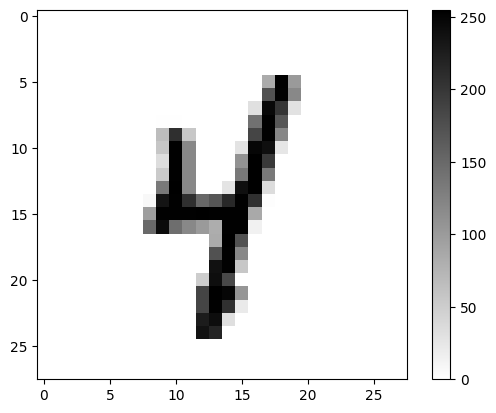

In [10]:
for imagen, etiqueta in datos_entremaniento.take(1):
  break

import matplotlib.pyplot as plt

#Mostrarlo en pantalla
plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.show()

### **Visualizar múltiples imágenes de entrenamiento**

Esta celda muestra una cuadrícula de 25 imágenes del conjunto de entrenamiento. Itera sobre las primeras 25 imágenes y las muestra en un formato de 5x5, lo que proporciona una visión general del tipo de datos que el modelo procesará.

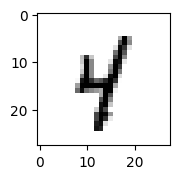

In [11]:
plt.figure(figsize=(10,10))
for i, (imagen, etiqueta) in enumerate(datos_entremaniento.take(25)):
  break
#Mostrarlo en pantalla
plt.subplot(5, 5, i+1)
plt.imshow(imagen, cmap=plt.cm.binary)

plt.show()

#Aqui empieza la parte 2 (El segundo video)

### **Definir la arquitectura del modelo de red neuronal**

Esta celda construye un modelo de red neuronal secuencial utilizando Keras. Contiene una capa `Flatten` para convertir la imagen 2D en un vector 1D, una capa `Dense` oculta con activación ReLU y una capa `Dense` de salida con activación Softmax para clasificación multi-clase.

In [13]:
modelo = tf.keras.Sequential([
    #784 datos de entrada
    tf.keras.layers.Flatten(input_shape=(28,28,1)), #1 = lanco y negro
    # # # Capa oculta
    tf.keras.layers.Dense(1),
    # Capa de salida
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### **Compilar el modelo**

Esta celda compila el modelo. Se especifica el optimizador (`adam`), la función de pérdida (`SparseCategoricalCrossentropy` para etiquetas enteras) y la métrica de evaluación (`accuracy`).

In [15]:
modelo.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

### **Configurar lotes de datos para entrenamiento y prueba**

Aquí se define el tamaño del lote (`TAMANO_LOTE`). Luego, los conjuntos de entrenamiento y prueba se configuran para repetir, barajar (solo entrenamiento) y dividirse en lotes, optimizando el proceso de entrenamiento.

In [16]:
TAMANO_LOTE = 32

datos_entrenamiento = datos_entrenamiento.repeat().shuffle(60000).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

### **Entrenar el modelo**

Esta celda inicia el entrenamiento del modelo. El modelo se ajusta a los `datos_entrenamiento` durante 10 `epochs`. `steps_per_epoch` se calcula para asegurar que todos los datos de entrenamiento se procesen en cada época.

In [19]:
import math

#Entrenar
entrenamiento = modelo.fit(
    datos_entrenamiento, epochs=10,
    steps_per_epoch=math.ceil(60000/TAMANO_LOTE)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.2462 - loss: 1.8550
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3346 - loss: 1.6508
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3769 - loss: 1.5645
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4036 - loss: 1.5268
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4196 - loss: 1.5143
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4232 - loss: 1.5017
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4245 - loss: 1.4980
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.4250 - loss: 1.4957
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4271 - loss: 1.4903
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.4246 - loss: 1.4902


### **Visualizar predicciones del modelo**

Esta celda define y utiliza funciones para graficar las predicciones del modelo. `graficar_imagen` muestra una imagen con la predicción (azul si es correcta, roja si es incorrecta). `graficar_valor_arreglo` muestra un gráfico de barras con las probabilidades de predicción para cada clase. Finalmente, se genera una cuadrícula de 25 imágenes con sus predicciones.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step


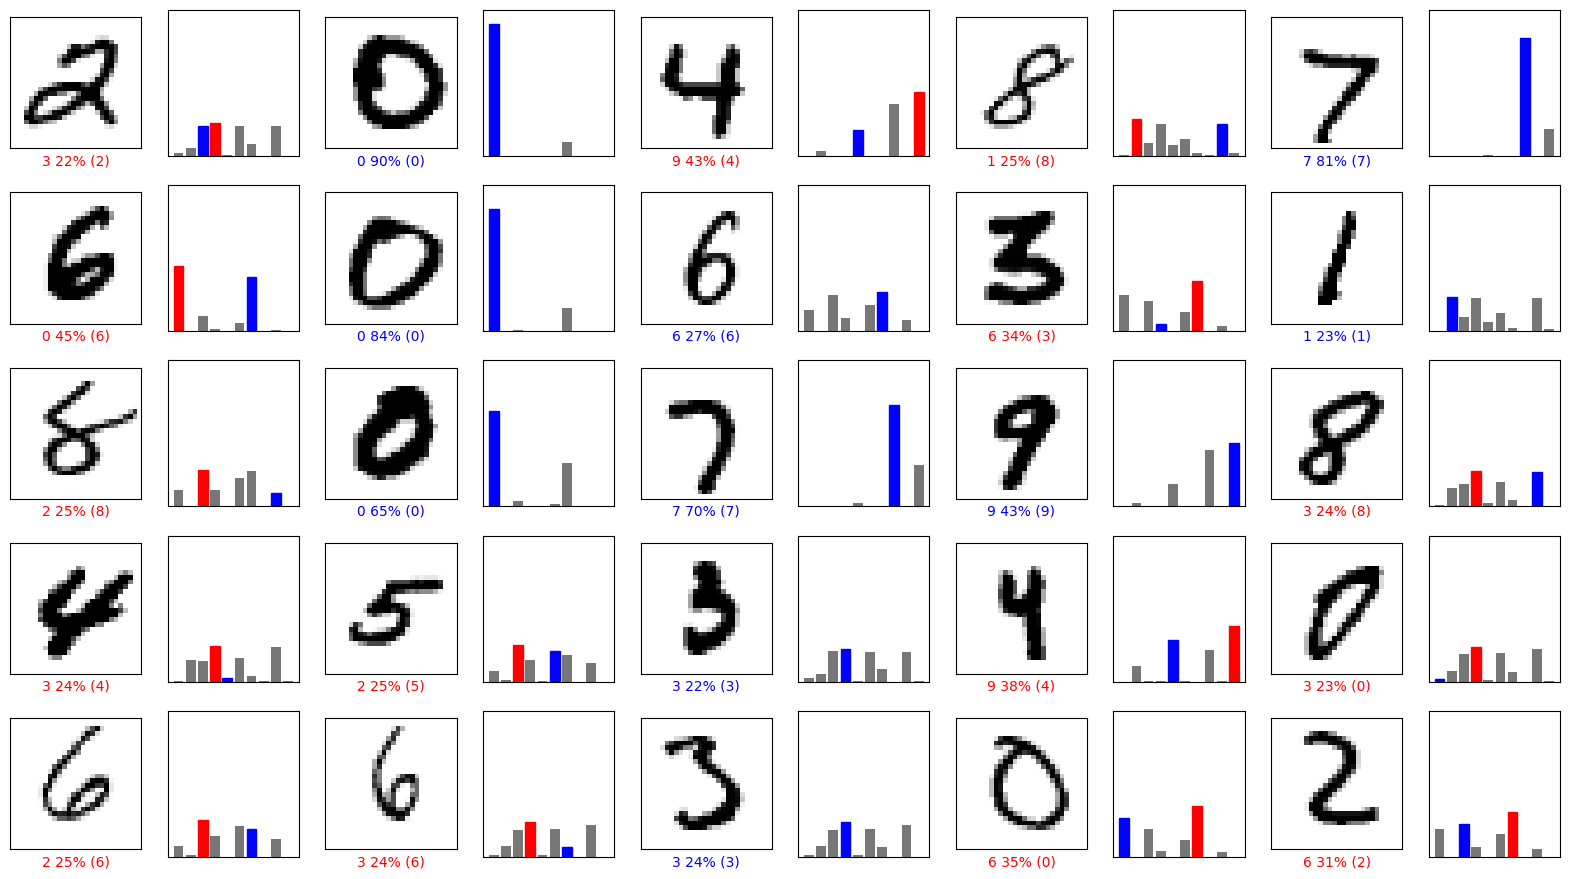

In [20]:
#Pintar una cuadricula con varias predicciones, y marcar si fue correcta (azul) o incorrecta (roja)
import numpy as np

for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
  imagenes_prueba = imagenes_prueba.numpy()
  etiquetas_prueba = etiquetas_prueba.numpy()
  predicciones = modelo.predict(imagenes_prueba)

def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
  arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img[...,0], cmap=plt.cm.binary)

  etiqueta_prediccion = np.argmax(arr_predicciones)
  if etiqueta_prediccion == etiqueta_real:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(nombres_clases[etiqueta_prediccion],
                                     100*np.max(arr_predicciones),
                                     nombres_clases[etiqueta_real]),
                                     color=color)

def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
  arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  grafica = plt.bar(range(10), arr_predicciones, color='#777777')
  plt.ylim([0, 1])
  etiqueta_prediccion = np.argmax(arr_predicciones)

  grafica[etiqueta_prediccion].set_color('red')
  grafica[etiqueta_real].set_color('blue')

filas = 5
columnas = 5
num_imagenes = filas*columnas
plt.figure(figsize=(2*2*columnas, 2*filas + 1))
for i in range(num_imagenes):
  plt.subplot(filas, 2*columnas, 2*i+1)
  graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
  plt.subplot(filas, 2*columnas, 2*i+2)
  graficar_valor_arreglo(i, predicciones, etiquetas_prueba)

#Por ultimo y lo menos importante:

## "Joven haga su trabajo por favor"

###### 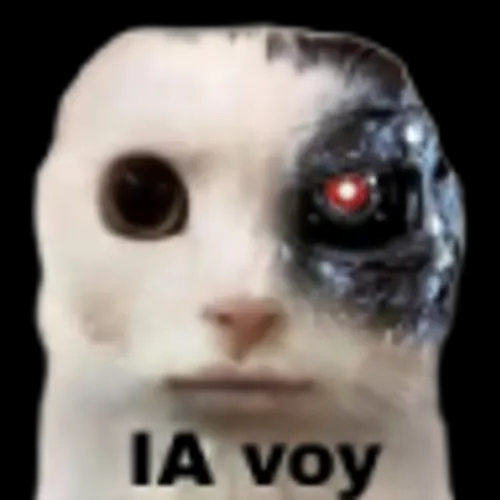

El chiste del gato que dice IA voy se refiere comunmente a utilizar inteligencia artificial para resolver los trabajos asignados de forma rapida.

La frase "Joven, haga su trabajo por favor" se suele usar seguido cuando un alumno no esta realizando trabajo en clase, por ello al utilizar la imagen del gato parcialmente robotico con la frase IA voy, se considera como un gesto comico.

*Explicacion generada por IA (Creanme)